In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

!pip install stanza
import stanza
stanza.download('uk')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 17.2 MB/s eta 0:00:00


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: uk (Ukrainian) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/uk/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources


[['zip', 'default.zip']]

In [ ]:
ua_stopwords = [
    'а', 'б', 'в', 'г', 'ґ', 'д', 'е', 'є', 'ж', 'з', 'и', 'і', 'ї', 'й',
    'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч',
    'ш', 'щ', 'ь', 'ю', 'я', 'на', 'зі', 'до', 'за', 'під', 'над', 'перед',
    'при', 'про', 'без', 'через', 'для', 'задля', 'від', 'відтак', 'по',
    'понад', 'попід', 'та', 'але', 'алеж', 'чи', 'або', 'що', 'щоб', 'як', 'коли',
    'якщо', 'хоч', 'хоча', 'бо', 'тому що', 'немов', 'немовби', 'немовбито',
    'не', 'ні', 'таки', 'же', 'ось', 'от', 'ачей', 'мабуть', 'навряд',
    'невже', 'хіба', 'тільки', 'лиш', 'лише', 'ти', 'він', 'вона', 'воно', 'ми', 'ви', 'вони', 'це', 'то', 'той',
    'те', 'такі', 'цей', 'ця', 'ці', 'свій', 'мій', 'твій', 'наш', 'ваш',
    'їхній', 'хто', 'який', 'чий', 'дехто', 'дещо', 'було', 'буду', 'був', 'була', 'були', 'щоб', 'вам', 'вас', 'весь',
    'все', 'всіх', 'завжди', 'навіть', 'адже', 'вздовж', 'замість', 'поза',
    'вниз', 'внизу', 'всередині', 'навколо', 'да', 'давай', 'більш', 'бути',
]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Data/collected_raw_data/'
df_telegram = pd.read_csv(path + 'telegram_news.csv')

In [ ]:
df_telegram.shape

(57170, 2)

In [ ]:
df_telegram.head()

,Date,Text
0,2026-03-16 23:51:09+00:00,"🛵 Групи БпЛА, що на півдні Одещини прямують у ..."
1,2026-03-16 23:31:21+00:00,🛵 Групи ворожих БпЛА у напрямку Кілії та Катла...
2,2026-03-16 23:21:32+00:00,🛵 Групи ворожих БпЛА у Чорному морі курсом на ...
3,2026-03-16 22:45:16+00:00,🛵 Ворожі БпЛА у напрямку Сергіївки з Чорного м...
4,2026-03-16 22:33:10+00:00,🛵 Ворожі БпЛА через Сумщину зі сходу у західно...


In [ ]:
def clean_text(text):
  text = re.sub(r'[^\w\s\u0400-\u04FF]', ' ', str(text)) # for keeping only Cyrillic and spaces
  text = re.sub(r'\s+', ' ', text).strip() # deleting extra widespaces
  text = text.lower() # lowercase for all text
  text = re.sub(r'\d+', ' ', text)  # for removing digits
  text = re.sub(r'http\S+|www\S+|t\.me\S+', ' ', str(text)) #for removing URLs
  return text

df_telegram['text_clean'] = df_telegram['Text'].apply(clean_text)
df_telegram[['Text', 'text_clean']].head()

,Text,text_clean
0,"🛵 Групи БпЛА, що на півдні Одещини прямують у ...",групи бпла що на півдні одещини прямують у нап...
1,🛵 Групи ворожих БпЛА у напрямку Кілії та Катла...,групи ворожих бпла у напрямку кілії та катлабугу
2,🛵 Групи ворожих БпЛА у Чорному морі курсом на ...,групи ворожих бпла у чорному морі курсом на та...
3,🛵 Ворожі БпЛА у напрямку Сергіївки з Чорного м...,ворожі бпла у напрямку сергіївки з чорного моря
4,🛵 Ворожі БпЛА через Сумщину зі сходу у західно...,ворожі бпла через сумщину зі сходу у західному...


In [ ]:
df_telegram['text_clean'] = df_telegram['Text'].apply(clean_text)
df_telegram['tokens'] = df_telegram['text_clean'].apply(lambda text: [t for t in text.split() if t not in ua_stopwords and len(t) > 2])

df_telegram[['Text', 'tokens']].head()

,Text,tokens
0,"🛵 Групи БпЛА, що на півдні Одещини прямують у ...","[групи, бпла, півдні, одещини, прямують, напря..."
1,🛵 Групи ворожих БпЛА у напрямку Кілії та Катла...,"[групи, ворожих, бпла, напрямку, кілії, катлаб..."
2,🛵 Групи ворожих БпЛА у Чорному морі курсом на ...,"[групи, ворожих, бпла, чорному, морі, курсом, ..."
3,🛵 Ворожі БпЛА у напрямку Сергіївки з Чорного м...,"[ворожі, бпла, напрямку, сергіївки, чорного, м..."
4,🛵 Ворожі БпЛА через Сумщину зі сходу у західно...,"[ворожі, бпла, сумщину, сходу, західному, напр..."


In [ ]:
df_telegram['tokens_str'] = df_telegram['tokens'].apply(lambda x: ' '.join(x))

In [ ]:
df_telegram['datetime'] = pd.to_datetime(df_telegram['Date']).dt.floor('h')

df_telegram[['Date', 'datetime']].head()

,Date,datetime
0,2026-03-16 23:51:09+00:00,2026-03-16 23:00:00+00:00
1,2026-03-16 23:31:21+00:00,2026-03-16 23:00:00+00:00
2,2026-03-16 23:21:32+00:00,2026-03-16 23:00:00+00:00
3,2026-03-16 22:45:16+00:00,2026-03-16 22:00:00+00:00
4,2026-03-16 22:33:10+00:00,2026-03-16 22:00:00+00:00


In [ ]:
df_telegram['datetime'].dtype

datetime64[ns, UTC]

In [ ]:
nlp = stanza.Pipeline('uk', processors='tokenize,lemma')

def lemmatize_uk(text):
    doc = nlp(text)
    return ' '.join([word.lemma for sent in doc.sentences for word in sent.words])

print("Starting lemmatization")
df_telegram['tokens_str'] = df_telegram['tokens_str'].apply(lemmatize_uk)
df_telegram['tokens_str'].head(3)

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: uk (Ukrainian):
| Processor | Package     |
---------------------------
| tokenize  | iu          |
| mwt       | iu          |
| lemma     | iu_nocharlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: lemma
INFO:stanza:Done loading processors!


Starting lemmatization


,tokens_str
0,група бпла південь одещини прямують напрямок і...
1,група ворожий бпла напрямок кілія катлабуга
2,група ворожий бпла чорний море курс татарбунари


In [ ]:
df_telegram_hourly = df_telegram.groupby('datetime')['tokens_str'].apply(lambda x: ' '.join(x)).reset_index() # for combining all messages per hour

df_telegram_hourly.shape

(19557, 2)

In [ ]:
# For converting lemmatized hourly text to numerical TF-IDF matrix
vectorizer = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(df_telegram_hourly['tokens_str'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{w}' for w in vectorizer.get_feature_names_out()]
)
tfidf_df['datetime'] = df_telegram_hourly['datetime'].values

print(f"TF-IDF shape: {tfidf_df.shape}")

TF-IDF shape: (19557, 101)


In [ ]:
import pickle
file_path = 'vectorizer_tg.pkl'

with open(file_path, "wb") as f:
    pickle.dump(vectorizer, f)

print(f"{file_path}")

vectorizer_tg.pkl


In [ ]:
tfidf_df['datetime'] = pd.to_datetime(tfidf_df['datetime']).dt.tz_localize(None)

In [ ]:
df_telegram_hourly.head()

,datetime,tokens_str
0,2022-02-24 21:00:00+00:00,важливо терміново соцмережа деякий зе поширюва...
1,2022-02-24 22:00:00+00:00,повітрянин сила завдати ворог суттєвий втрата ...
2,2022-02-25 07:00:00+00:00,вибухи аеродромий міллєрово ростовській област...
3,2022-02-25 09:00:00+00:00,терміново кіберполіція створити спеціальний бо...
4,2022-02-25 10:00:00+00:00,бути україна stoprussia бути україна stoprussi...


In [ ]:
processed_path = '/content/drive/MyDrive/Data/processed_data/'
df_telegram[['datetime', 'Text', 'text_clean', 'tokens_str']].to_csv(processed_path + 'telegram_eda.csv', index=False) # for EDA

In [ ]:
tfidf_df.to_csv(processed_path  + 'telegram_tfidf.csv', index=False)

In [ ]:
df_telegram[['datetime', 'Text', 'text_clean', 'tokens_str']].to_csv('telegram_eda.csv', index=False)

tfidf_df.to_csv('telegram_tfidf.csv', index=False)

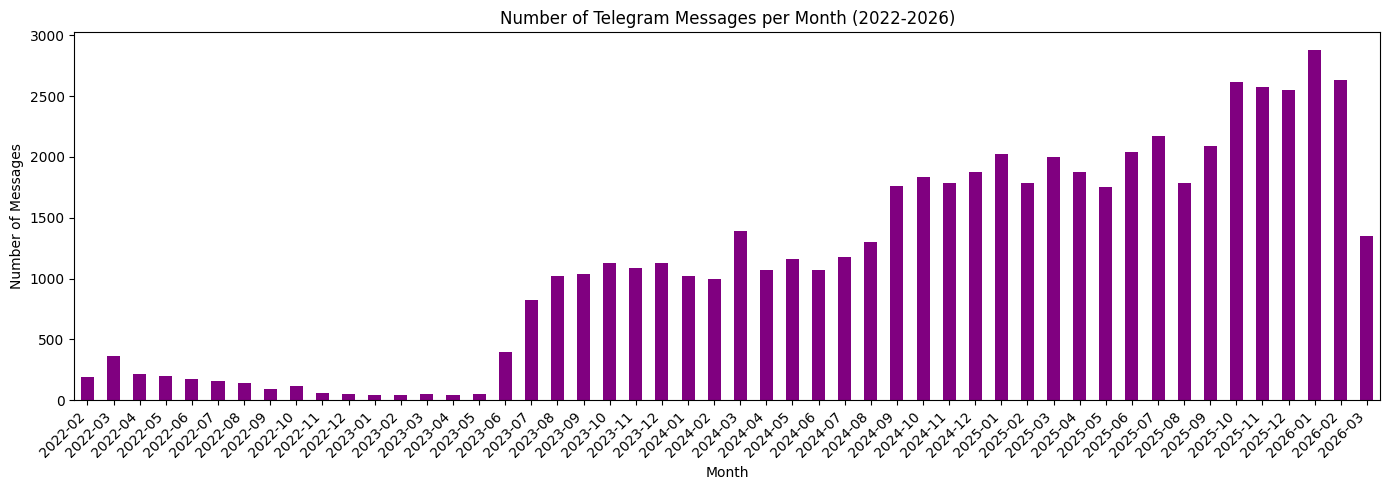

In [ ]:
df_telegram['month'] = df_telegram['datetime'].dt.tz_localize(None).dt.to_period('M')

plt.figure(figsize=(14, 5))
df_telegram.groupby('month').size().plot(kind='bar', color='purple')
plt.title('Number of Telegram Messages per Month (2022-2026)')
plt.xlabel('Month')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_telegram['hour'] = df_telegram['datetime'].dt.hour

plt.figure(figsize=(10, 5))
df_telegram.groupby('hour').size().plot(kind='bar', color='purple')
plt.title('Message Activity by Hour of Day (2022-2026)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Messages')
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

all_tokens = ' '.join(df_telegram['tokens_str']).split()
word_freq = Counter(all_tokens).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 6))
plt.barh(words, counts, color='purple')
plt.title('Top-20 Most Frequent Words in Telegram Messages')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

NameError: name 'df_telegram' is not defined

In [ ]:
full_hours = pd.date_range(
    start='2022-02-24',
    end='2026-03-16',
    freq='h',
    tz='UTC'
)

hours_without = len(full_hours) - len(df_telegram_hourly)

coverage = pd.Series({
    'Hours with messages': len(df_telegram_hourly),
    'Hours without messages': hours_without
})

plt.figure(figsize=(6, 6))
plt.pie(coverage.values, labels=coverage.index,
        autopct='%1.1f%%', colors=['purple', 'lightgray'])
plt.title('Hourly Coverage of Telegram Data (2022-2026)')
plt.tight_layout()
plt.show()

In [ ]:
tfidf_means = tfidf_df.drop(columns=['datetime']).mean().sort_values(ascending=False).head(20)

tfidf_means.index = tfidf_means.index.str.replace('tfidf_', '')

plt.figure(figsize=(10, 6))
tfidf_means.plot(kind='barh', color='purple')
plt.title('Top-20 Words by Average TF-IDF Weight in Telegram Messages')
plt.xlabel('Average TF-IDF Weight')
plt.ylabel('Word')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
df_telegram['msg_length'] = df_telegram['tokens_str'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
df_telegram['msg_length'].hist(bins=50, color='purple')
plt.title('Distribution of Message Length (in tokens)')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Messages')
plt.tight_layout()
plt.show()